In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
pip install pandas yfinance

Note: you may need to restart the kernel to use updated packages.


In [3]:
import yfinance as yf

start_date = '2021-01-01'
end_date = '2025-12-31'
stock_no = '0050.TW'

stock = yf.Ticker(stock_no)
stock_data = stock.history(start = start_date, end = end_date)

stock_data.head(10)

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains
Date,,,,,,,,
2021-01-04 00:00:00+08:00,26.317520,26.812859,26.274448,26.780554,24563188,0.0,0.0,0.0
2021-01-05 00:00:00+08:00,26.748252,26.845167,26.651339,26.834398,18926280,0.0,0.0,0.0
2021-01-06 00:00:00+08:00,27.157444,27.383577,26.726716,27.125139,42348292,0.0,0.0,0.0
2021-01-07 00:00:00+08:00,27.254359,27.782001,27.254359,27.760464,26764652,0.0,0.0,0.0
2021-01-08 00:00:00+08:00,28.126586,28.266571,27.900452,28.255802,51960980,0.0,0.0,0.0
2021-01-11 00:00:00+08:00,28.255802,28.492704,28.105048,28.492704,40583424,0.0,0.0,0.0
2021-01-12 00:00:00+08:00,28.492703,28.675761,28.341949,28.449631,43497448,0.0,0.0,0.0
2021-01-13 00:00:00+08:00,28.589624,29.171107,28.578855,29.138803,42755604,0.0,0.0,0.0
2021-01-14 00:00:00+08:00,29.074184,29.084953,28.718834,28.869589,48001796,0.0,0.0,0.0


In [4]:
stock_data.shape

(1212, 8)

In [5]:
stock_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1212 entries, 2021-01-04 00:00:00+08:00 to 2025-12-30 00:00:00+08:00
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Open           1212 non-null   float64
 1   High           1212 non-null   float64
 2   Low            1212 non-null   float64
 3   Close          1212 non-null   float64
 4   Volume         1212 non-null   int64  
 5   Dividends      1212 non-null   float64
 6   Stock Splits   1212 non-null   float64
 7   Capital Gains  1212 non-null   float64
dtypes: float64(7), int64(1)
memory usage: 85.2 KB


In [6]:
data = stock_data.copy(deep = True)
data_2025 = data['2025-01-01':'2025-12-31'] 
data_2025.shape

(242, 8)

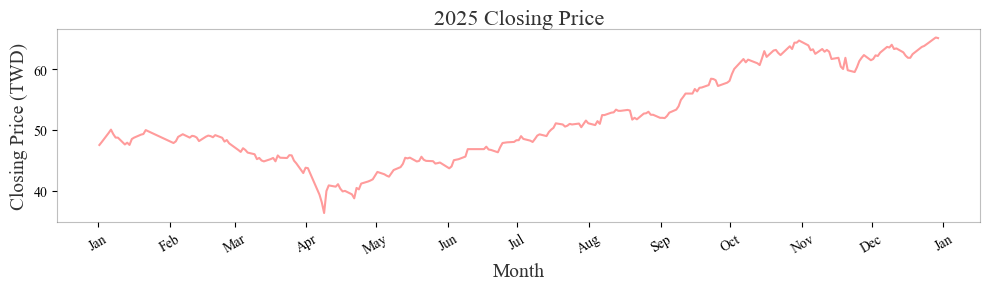

In [7]:
# 2025 Closing price
x = data_2025.index
y = data_2025["Close"]

plt.rcParams["font.family"] = "Times New Roman"
plt.figure(figsize=(10,3))
plt.plot(x, y, color="#ff9b9b")
plt.title("2025 Closing Price", y=0.98, fontsize=16, fontweight="regular", alpha = 0.8)
plt.xlabel("Month", fontsize = 14, alpha = 0.8)
plt.ylabel("Closing Price (TWD)",fontsize = 14, alpha = 0.8)
plt.xticks(rotation=30) 

import matplotlib.dates as mdates
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b'))
plt.gca().tick_params(axis="x", colors="black") # plt.gca().tick_params(axis="x", color="black", labelcolor="black")

plt.gca().spines["top"].set_color("gray")
plt.gca().spines["top"].set_alpha(0.5)
plt.gca().spines["right"].set_color("gray")
plt.gca().spines["right"].set_alpha(0.5)
plt.gca().spines["bottom"].set_color("gray")
plt.gca().spines["bottom"].set_alpha(0.5)
plt.gca().spines["left"].set_color("gray")
plt.gca().spines["left"].set_alpha(0.5)

plt.tight_layout()
plt.show()

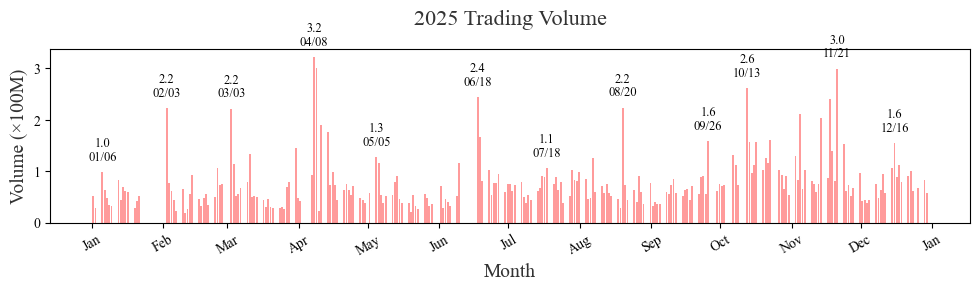

In [8]:
# Volume
x = data_2025.index
y = data_2025["Volume"]

plt.figure(figsize=(10,3))
plt.bar(x, y, color="#ff9b9b")
plt.title("2025 Trading Volume", y=0.98, fontsize=16, fontweight="regular", alpha = 0.8, pad = 20)
plt.xlabel("Month", fontsize = 14, alpha = 0.8)
plt.ylabel("Volume (×100M)",fontsize = 14, alpha = 0.8)
plt.xticks(rotation=30) 
import matplotlib.ticker as mticker
# make y axis in 100M： Volume/1e8
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, pos: f"{v/1e8:g}"))
# Set x-axis ticks to month abbreviations
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b'))
plt.gca().tick_params(axis="x", colors="black") 

# Find the maximum trading volume for each month
monthly_max = y.groupby(pd.Grouper(freq="M")).transform('max')
is_monthly_max = y.eq(monthly_max) 
# Annotate the value on each month’s highest-volume bar
for dt, vol in y[is_monthly_max].items():
    plt.annotate(f"{vol/1e8:.1f}\n{dt:%m/%d}", 
                xy=(dt, vol),
                xytext=(0, 6),
                textcoords="offset points",
                ha="center", va="bottom",
                fontsize=9)

plt.tight_layout()
plt.show()

Date
2025-01-01 00:00:00+08:00     799391396
2025-02-01 00:00:00+08:00    1209766096
2025-03-01 00:00:00+08:00    1441956364
2025-04-01 00:00:00+08:00    1935918768
2025-05-01 00:00:00+08:00    1098391788
2025-06-01 00:00:00+08:00    1343191326
2025-07-01 00:00:00+08:00    1630366496
2025-08-01 00:00:00+08:00    1485835277
2025-09-01 00:00:00+08:00    1367068947
2025-10-01 00:00:00+08:00    2236356612
2025-11-01 00:00:00+08:00    2342363421
2025-12-01 00:00:00+08:00    1614956135
Freq: MS, Name: Volume, dtype: int64


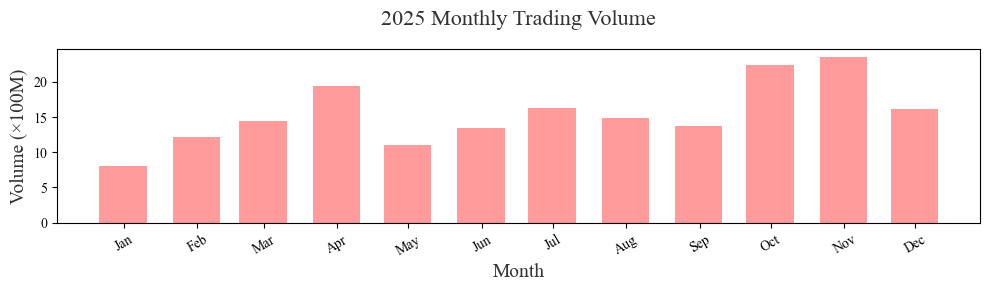

In [9]:
# Use month-start (MS) as the index (01-01, 02-01...)
monthly_vol = data_2025["Volume"].resample("MS").sum()  # MS = month start
x = monthly_vol.index
y = monthly_vol.values

plt.figure(figsize=(10,3))
plt.bar(x, y, color="#ff9b9b", width=20)
plt.title("2025 Monthly Trading Volume", y=0.98, fontsize=16, fontweight="regular", alpha = 0.8, pad = 20)
plt.xlabel("Month", fontsize = 14, alpha = 0.8)
plt.ylabel("Volume (×100M)",fontsize = 14, alpha = 0.8)
plt.xticks(rotation=30) 

# make y axis in 100M： Volume/1e8
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, pos: f"{v/1e8:g}"))
# Set x-axis ticks to month abbreviations
monthly_vol.sort_index(inplace = True)

print(monthly_vol)
# Set x-axis ticks to month abbreviations
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b'))
plt.gca().tick_params(axis="x", colors="black") 

plt.tight_layout()
plt.show()

### Returns

In [11]:
daily_return = data_2025["Close"].pct_change().dropna()
daily_return

Date
2025-01-03 00:00:00+08:00    0.010049
2025-01-06 00:00:00+08:00    0.031377
2025-01-07 00:00:00+08:00    0.011130
2025-01-08 00:00:00+08:00   -0.014922
2025-01-09 00:00:00+08:00   -0.011423
                               ...   
2025-12-23 00:00:00+08:00    0.004732
2025-12-24 00:00:00+08:00    0.002355
2025-12-26 00:00:00+08:00    0.008614
2025-12-29 00:00:00+08:00    0.013199
2025-12-30 00:00:00+08:00   -0.001533
Name: Close, Length: 241, dtype: float64

In [12]:
daily_return.describe()

count    241.000000
mean       0.001433
std        0.015663
min       -0.100000
25%       -0.006617
50%        0.001579
75%        0.009724
max        0.099863
Name: Close, dtype: float64

In [13]:
average_daily_return = daily_return.describe()["mean"]
print(f"Average Daily Return: {average_daily_return:.2%}")

Average Daily Return: 0.14%


In [14]:
total_return = (1 + daily_return).prod() - 1
print(f"Total Return: {total_return:.2%}")

Total Return: 37.11%


In [15]:
n = daily_return.shape[0]  # number of trading days in 2025
n

241

In [16]:
n = daily_return.shape[0]  # number of trading days in 2025
annual_return = (1 + total_return) ** (252 / n) - 1
print(f"Annual Return: {annual_return:.2%}")

Annual Return: 39.10%


In [17]:
import numpy as np
def annualized_sharpe_ratio(daily_returns, rf_annual=0.0, periods=252):
    """
    rf_annual: annual risk-free rate (e.g., 0.045 for 4.5%)
    periods: trading days per year (252 for daily)
    """
    rf_daily = (1 + rf_annual) ** (1 / periods) - 1  # convert annual rf to daily
    excess = daily_returns - rf_daily

    mean_excess = excess.mean()
    std_excess = excess.std(ddof=1)  # sample std
    sharpe = (mean_excess / std_excess) * np.sqrt(periods)
    return sharpe
daily_returns = daily_return.values
# 1) rf = 0
sharpe0 = annualized_sharpe_ratio(daily_returns, rf_annual=0.0)

# 2) rf = 4.5% (example)
sharpe_rf = annualized_sharpe_ratio(daily_returns, rf_annual=0.045)

sharpe0, sharpe_rf
print(f"Sharpe0: {sharpe0:.2}\n"f"Sharpe_rf: {sharpe_rf:.2}")

Sharpe0: 1.5
Sharpe_rf: 1.3


### KPI

In [19]:
import numpy as np

def calculate_kpis(returns_df, benchmark_col="^TWII", target_col="0050.TW"):
    # Accepts a Series or a DataFrame (multiple return columns).
    if isinstance(returns_df, pd.Series):
        returns_df = returns_df.to_frame(name=target_col)

    stats = {}

    # 1) cumulative return
    stats["Total Return"] = (1 + returns_df[target_col]).prod() - 1

    # 2) annualized volatility
    stats["Vol"] = returns_df[target_col].std() * np.sqrt(252)

    # 3) maximum drawdown (MDD)
    cum_price = (1 + returns_df[target_col]).cumprod()
    peak = cum_price.cummax()
    stats["MDD"] = ((cum_price - peak) / peak).min()

    # 4) Beta (only calculated when benchmark returns are available)
    if benchmark_col in returns_df.columns:
        covariance = returns_df[[target_col, benchmark_col]].cov().iloc[0, 1]
        benchmark_var = returns_df[benchmark_col].var()
        stats["Beta"] = covariance / benchmark_var if benchmark_var != 0 else np.nan
    else:
        stats["Beta"] = np.nan 

    return stats


In [20]:
stats = calculate_kpis(daily_return)
stats

{'Total Return': 0.37110802668278997,
 'Vol': 0.24864460166156552,
 'MDD': -0.2748499560153493,
 'Beta': nan}

In [21]:
df_30d_rate = ((data_2025["Close"].shift(-30) / data_2025["Close"])-1).dropna()
df_30d_rate

Date
2025-01-02 00:00:00+08:00    0.025054
2025-01-03 00:00:00+08:00    0.001666
2025-01-06 00:00:00+08:00   -0.023542
2025-01-07 00:00:00+08:00   -0.045203
2025-01-08 00:00:00+08:00   -0.053146
                               ...   
2025-11-11 00:00:00+08:00    0.012719
2025-11-12 00:00:00+08:00    0.010285
2025-11-13 00:00:00+08:00    0.023847
2025-11-14 00:00:00+08:00    0.057536
2025-11-17 00:00:00+08:00    0.052504
Name: Close, Length: 212, dtype: float64

In [22]:
print(f"In 2025, the average return from holding 0050TW for 30 days and then selling was {df_30d_rate.describe()['mean']:.1%}.")

In 2025, the average return from holding 0050TW for 30 days and then selling was 4.0%.


### Controls

In [24]:
def data_quality_control(df, threshold = 0.09):
    if isinstance(df, pd.Series):
        df = df.to_frame(name=df.name or "returns")

    # checks
    missing = df.isnull().sum().sum()
    trading_days = len(df)

    # outliers（|return| > threshold）
    mask = df.abs() > threshold

    # Create a DataFrame listing the date and value for each outlier.
    outliers = (
        df.where(mask)
          .stack()
          .rename("value")
          .reset_index()
          .rename(columns={"level_0": "Date", "level_1": "Column"})
          .sort_values("Date")
    )

    checks = {
        "Missing Values": int(missing),
        "Trading Days": int(trading_days),
        "Outlier Alert": not outliers.empty,
        "Outlier Count": int(len(outliers)),
        "Outlier Threshold": threshold
    }
    
    # PASS/FAIL rules 
    pass_missing = (missing == 0)
    expected_trading_days = df["Close"].dropna().shape[0]
    tolerance_days = 2 # customized
    outlier_alert = not outliers.empty
    
    if expected_trading_days is None:
        pass_days = True   # Skip the trading-day count check when no expected value is given.
    else:
        pass_days = abs(trading_days - expected_trading_days) <= tolerance_days

    pass_outlier = (outlier_alert == False)  # PASS if max(|daily return|) ≤ 9%

    overall_pass = pass_missing and pass_days and pass_outlier

    return checks, outliers, overall_pass


quality_report, outliers_df, overall_pass = data_quality_control(daily_return, threshold = 0.09)
quality_report

{'Missing Values': 0,
 'Trading Days': 241,
 'Outlier Alert': True,
 'Outlier Count': 2,
 'Outlier Threshold': 0.09}

In [25]:
outliers_df

,Date,Column,value
0,2025-04-07 00:00:00+08:00,Close,-0.100000
1,2025-04-10 00:00:00+08:00,Close,0.099863


In [26]:
overall_pass

False

### KPI Summary Table

In [28]:
pd.set_option("display.max_colwidth", 200) # Set the maximum displayed column width to 200 characters.

kpi_summary = pd.DataFrame(
    {
        "KPI Metric": ["Period Return", "Max Drawdown(MDD)", r"Beta ($\beta$)", "Data Quality"],
        "2025 Value": [annual_return, stats["MDD"], stats["Beta"], overall_pass],
        "Notes": [
            "Cumulative return for full year 2025.",
            "Largest peak-to-trough decline within the year; downside risk.",
            "Above 1.0 means more sensitive than the market (more aggressive).",
            "True if no missing values, trading days align with the TWSE calendar, and no outliers."
           ],
    }
)
kpi_summary

,KPI Metric,2025 Value,Notes
0,Period Return,0.391003,Cumulative return for full year 2025.
1,Max Drawdown(MDD),-0.27485,Largest peak-to-trough decline within the year; downside risk.
2,Beta ($\beta$),NaN,Above 1.0 means more sensitive than the market (more aggressive).
3,Data Quality,False,"True if no missing values, trading days align with the TWSE calendar, and no outliers."


### Conclusion
In 2025, 0050TW delivered a strong overall performance: it gained 37.11% over 241 trading days (annualized to 39.10%). On average, a 30-day holding period produced a +4.0% return, suggesting broadly positive momentum across the year.